In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_INPUT_SYMBOLS = 13
NUM_OUTPUT_SYMBOLS = 12

SPY = 0
SCOUT = 1
MINER = 2
SERGEANT = 3
LIEUTENANT = 4
CAPTAIN = 5
MAJOR = 6
COLONEL = 7
GENERAL = 8
MARSHAL = 9
BOMB = 10
FLAG = 11
START = 12


COUNTS = {
    SPY: 1, SCOUT: 8, MINER: 5, SERGEANT: 4, LIEUTENANT: 4,
    CAPTAIN: 4, MAJOR: 3, COLONEL: 2, GENERAL: 1, MARSHAL: 1,
    BOMB: 6, FLAG: 1
}


HUMAN_READABLE = {
    SPY: "1", SCOUT: "2", MINER: "3", SERGEANT: "4", LIEUTENANT: "5",
    CAPTAIN: "6", MAJOR: "7", COLONEL: "8", GENERAL: "9", MARSHAL: "M",
    BOMB: "B", FLAG: "F"
}


def get_mirrored(setup):
    return setup[9::-1] + setup[19:9:-1] + setup[29:19:-1] + setup[39:29:-1]


def validate_setup(setup):
    counts = COUNTS.copy()
    for piece in setup:
        if counts[piece] == 0:
            return False
        counts[piece] -= 1
    return True


def plot_setup(setup, tile_size=0.6, fontsize=15, ax=None):

    num_rows, num_columns = 4, 10
    if ax is None:
        figsize = (num_columns * tile_size, num_rows * tile_size)
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=figsize)
    ax.set_xlim(0, num_columns)
    ax.set_ylim(0, num_rows + 1)

    for row, col in [(-1, 2), (-1, 3), (-1, 6), (-1, 7)]:
        rect = patches.Rectangle((col, num_rows - row - 1), width=1, height=1,
                                 linewidth=1, edgecolor='none',
                                 facecolor='lightblue', alpha=0.5)
        ax.add_patch(rect)

    for i in range(len(setup)):
        row = i // num_columns
        column = i % num_columns
        ax.text(column + 0.5, num_rows - row - 0.5, HUMAN_READABLE[setup[i]],
                ha='center', va='center', fontsize=fontsize)

    ax.set_xticks(range(num_columns + 1))
    ax.set_yticks(range(num_rows + 1))
    ax.grid(True)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)


def read_setups(path, unique=True, num_max_setups=None, include_mirrored=False):
    setups = []
    with open(path, "r") as file:
        reader = csv.reader(file)
        for i, row in enumerate(reader):
            if i == num_max_setups:
                break
            setups.append(tuple(int(piece) for piece in row))
    if unique:
        setups = list(set(setups))
    if include_mirrored:
        setups += [get_mirrored(setup) for setup in setups]
    return setups


class SetupsDataset(Dataset):

    def __init__(self, setups):
        self.setups = [torch.tensor([START] + list(setup), dtype=torch.long)
                       for setup in setups]

    def __getitem__(self, item):
        return F.one_hot(self.setups[item][:-1]).float(), self.setups[item][1:]

    def __len__(self):
        return len(self.setups)


class Model(nn.Module):

    def __init__(self, hidden_size=300):
        super().__init__()
        self.lstm = nn.LSTM(input_size=NUM_INPUT_SYMBOLS, hidden_size=hidden_size,
                            num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, NUM_OUTPUT_SYMBOLS)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden


def train_single_epoch(model, dataloader, optimizer, criterion):
    model.train()
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        output, hidden = model(inputs)
        loss = criterion(output.view(-1, NUM_OUTPUT_SYMBOLS), targets.view(-1))
        loss.backward()
        optimizer.step()


def evaluate(model, dataloader):
    model.eval()
    total_loss = 0.0
    num_samples = 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            output, hidden = model(inputs)
            output = output.view(-1, NUM_OUTPUT_SYMBOLS)
            targets = targets.view(-1)
            loss = F.cross_entropy(output, targets, reduction='sum')
            total_loss += loss.item()
            num_samples += targets.size(0)
    return total_loss / num_samples


def plot_loss_curves(train_loss_per_epoch, val_loss_per_epoch, best_epoch=None,
                     figsize=(6, 4)):
    plt.figure(figsize=figsize)
    x_axis_values = list(range(1, len(train_loss_per_epoch) + 1))
    plt.plot(x_axis_values, train_loss_per_epoch, color="blue", label="train loss")
    plt.plot(x_axis_values, val_loss_per_epoch, color="red", label="validation loss")
    if best_epoch is not None:
        plt.axvline(x=best_epoch, linestyle="--", color="green", label="best model")
    plt.legend()
    plt.ylabel("Loss")
    plt.xlabel("Epochs")
    plt.tight_layout()
    plt.show()


def save_model(filename, model, optimizer, train_losses, val_losses, epoch):
    model_info = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'epoch': epoch,
             }
    torch.save(model_info, filename)


def generate_setup(model):
    setup = []
    distributions = []
    counts = COUNTS.copy()
    hidden = None
    cur_piece = START
    for _ in range(40):
        model_input = F.one_hot(
               torch.tensor([cur_piece]), num_classes=NUM_INPUT_SYMBOLS).float()
        out, hidden = model(model_input, hidden)
        out = out.squeeze()
        for piece, count in counts.items():
            if count == 0:
                out[piece] = float('-inf')
        distribution = F.softmax(out, dim=0)
        distributions.append(distribution)
        cur_piece = torch.multinomial(distribution, 1).item()
        counts[cur_piece] -= 1
        setup.append(cur_piece)
    return setup, distributions

In [ ]:
all_setups = read_setups("setups.csv", num_max_setups=None, include_mirrored=True)
train_data, val_data = train_test_split(all_setups, train_size=0.9)

train_dataset = SetupsDataset(train_data)
val_dataset = SetupsDataset(val_data)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True)

model = Model().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion =  nn.CrossEntropyLoss()
num_epochs = 50

In [ ]:
train_loss_per_epoch = []
val_loss_per_epoch = []
min_val_loss = float('inf')
best_epoch = -1

for epoch in range(1, num_epochs + 1):
    train_single_epoch(model, train_dataloader, optimizer, criterion)
    train_loss = evaluate(model, train_dataloader)
    val_loss = evaluate(model, val_dataloader)
    print(f"Epoch: {epoch}, Train Loss: {round(train_loss, 3)}, "
          f"Val Loss: {round(val_loss, 3)}")
    train_loss_per_epoch.append(train_loss)
    val_loss_per_epoch.append(val_loss)
    if val_loss < min_val_loss:
        min_val_loss = val_loss
        best_epoch = epoch
        save_model("model.pth", model, optimizer, train_loss_per_epoch,
                   val_loss_per_epoch, epoch)

model = model.cpu()

Epoch: 1, Train Loss: 1.669, Val Loss: 1.676
Epoch: 2, Train Loss: 1.602, Val Loss: 1.613
Epoch: 3, Train Loss: 1.565, Val Loss: 1.58
Epoch: 4, Train Loss: 1.536, Val Loss: 1.557
Epoch: 5, Train Loss: 1.515, Val Loss: 1.54
Epoch: 6, Train Loss: 1.495, Val Loss: 1.526
Epoch: 7, Train Loss: 1.483, Val Loss: 1.519
Epoch: 8, Train Loss: 1.469, Val Loss: 1.51
Epoch: 9, Train Loss: 1.46, Val Loss: 1.506
Epoch: 10, Train Loss: 1.45, Val Loss: 1.5
Epoch: 11, Train Loss: 1.443, Val Loss: 1.498
Epoch: 12, Train Loss: 1.438, Val Loss: 1.496
Epoch: 13, Train Loss: 1.429, Val Loss: 1.492
Epoch: 14, Train Loss: 1.424, Val Loss: 1.49
Epoch: 15, Train Loss: 1.419, Val Loss: 1.488
Epoch: 16, Train Loss: 1.417, Val Loss: 1.488
Epoch: 17, Train Loss: 1.41, Val Loss: 1.488
Epoch: 18, Train Loss: 1.407, Val Loss: 1.485
Epoch: 19, Train Loss: 1.403, Val Loss: 1.486
Epoch: 20, Train Loss: 1.399, Val Loss: 1.483
Epoch: 21, Train Loss: 1.396, Val Loss: 1.485
Epoch: 22, Train Loss: 1.41, Val Loss: 1.494
Epoch: 

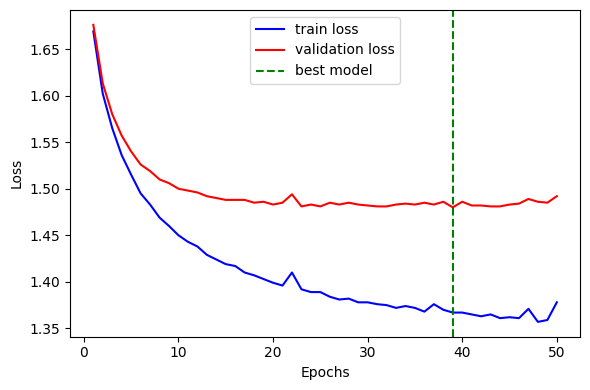

In [ ]:
plot_loss_curves(train_loss_per_epoch, val_loss_per_epoch, best_epoch)

In [ ]:
saved_model = torch.load("model.pth", weights_only=True)

model = Model()
model.load_state_dict(saved_model['model_state_dict'])

<All keys matched successfully>

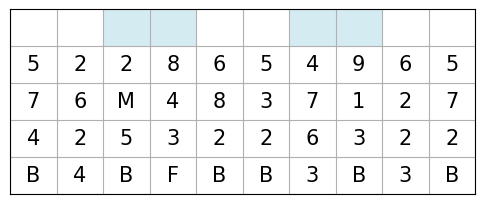

In [ ]:
generated_setup, distributions = generate_setup(model)
plot_setup(generated_setup)

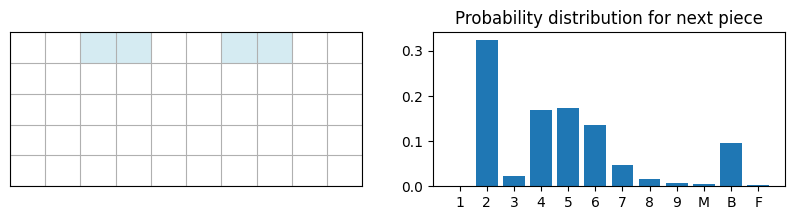

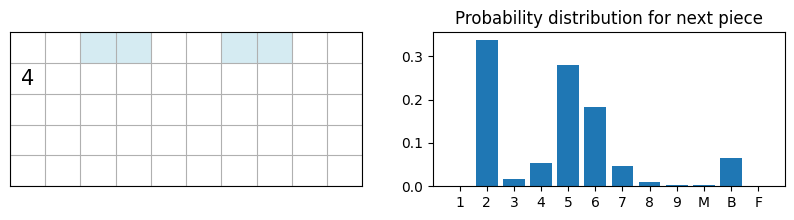

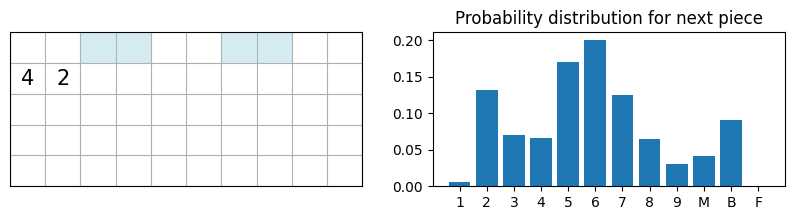

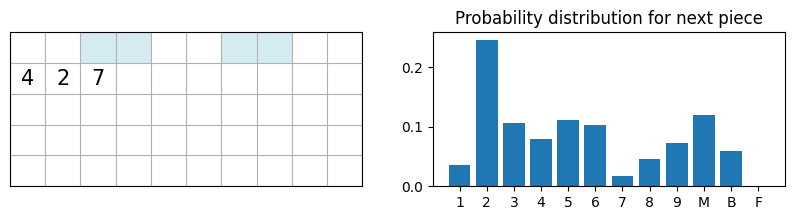

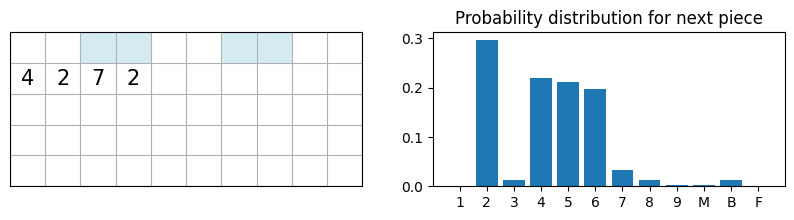

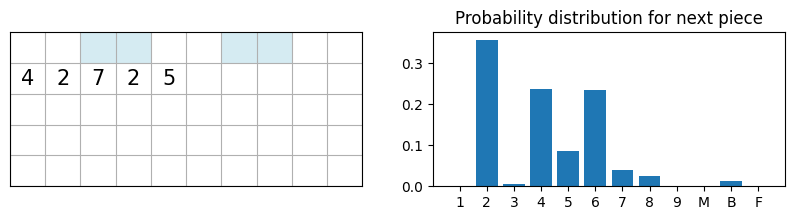

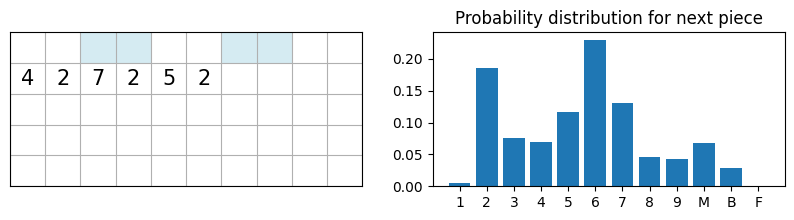

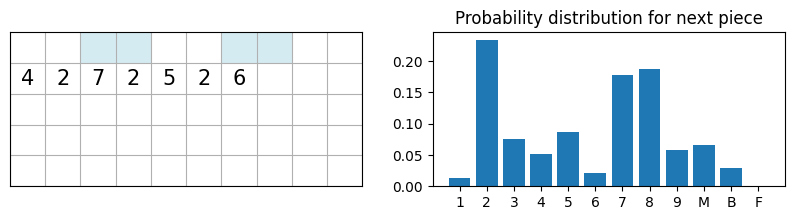

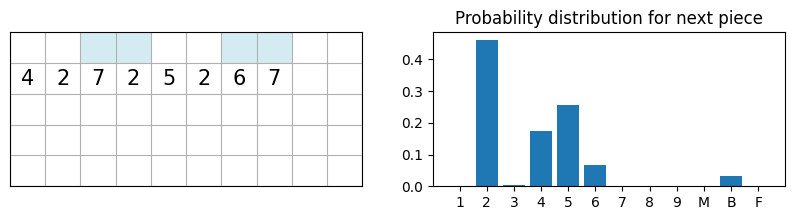

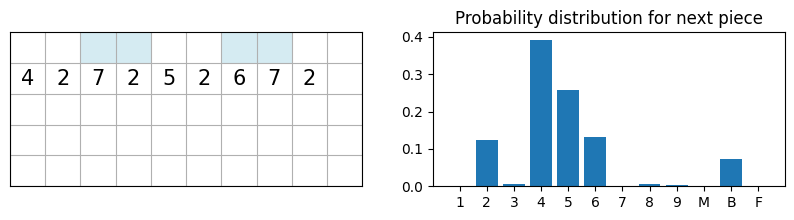

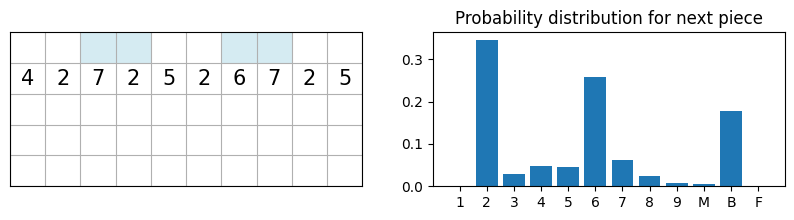

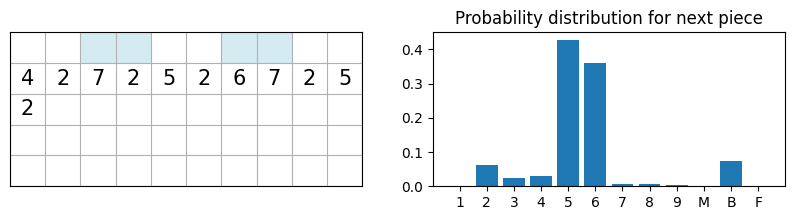

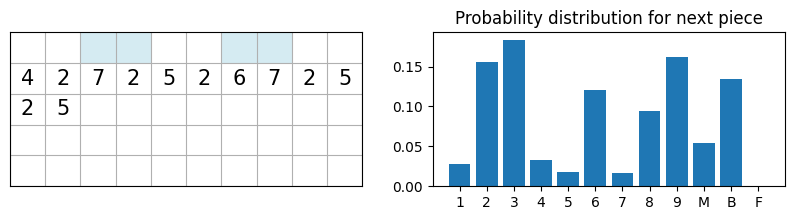

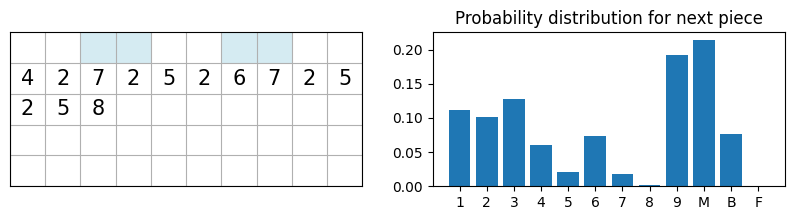

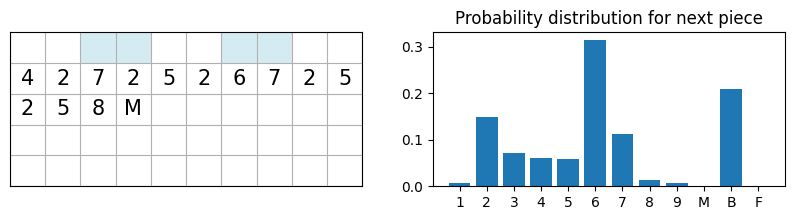

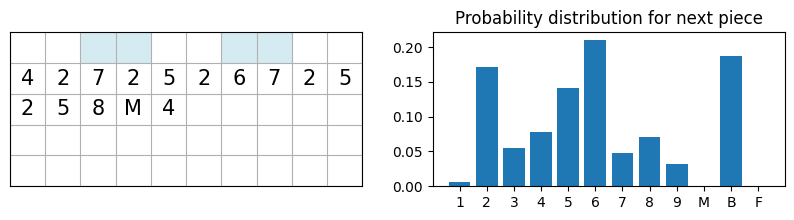

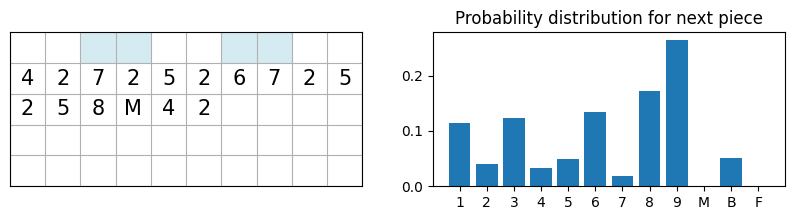

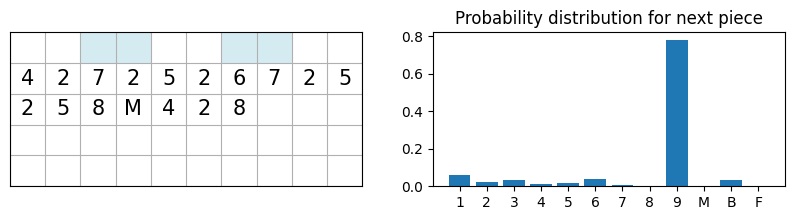

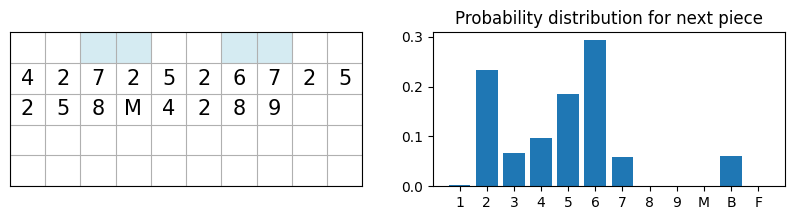

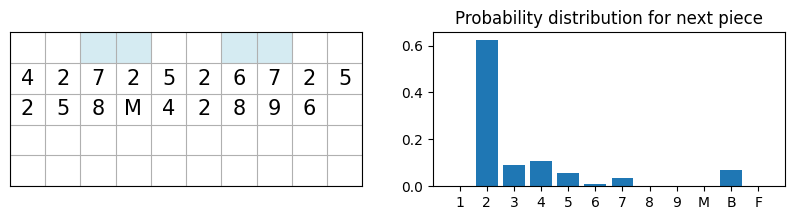

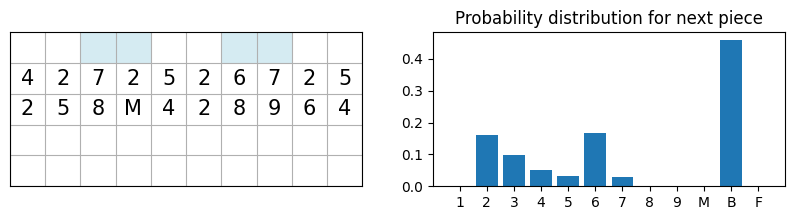

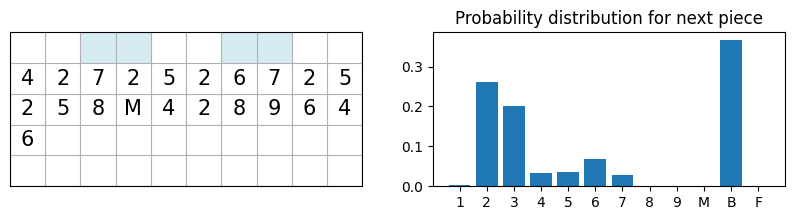

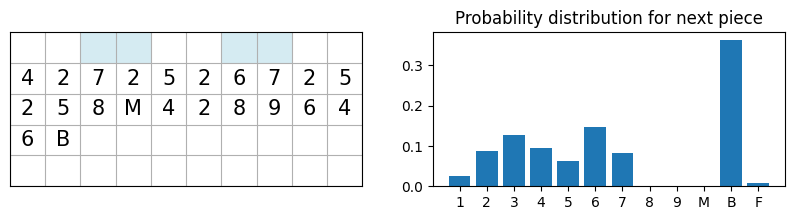

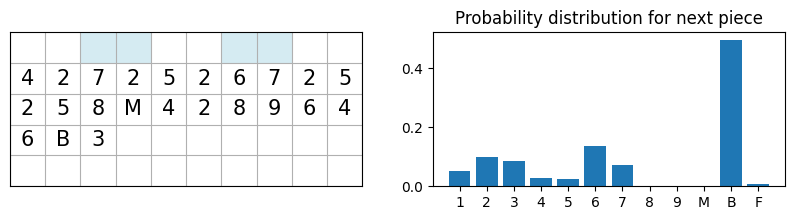

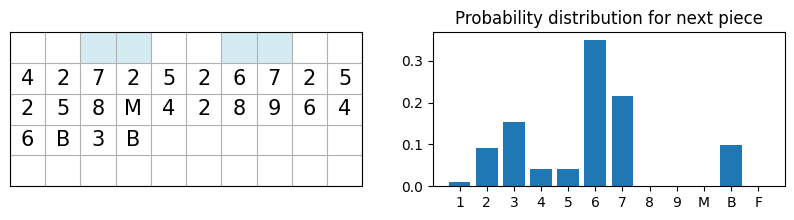

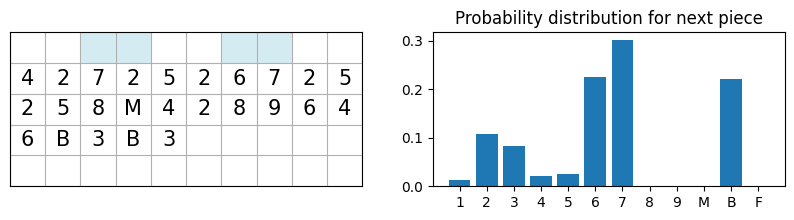

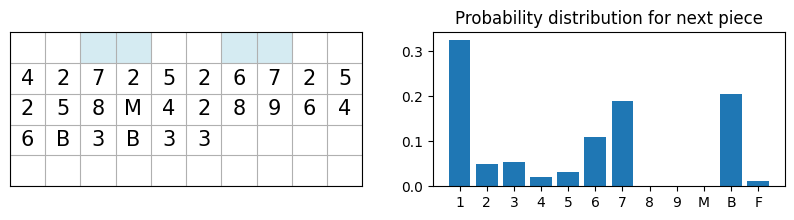

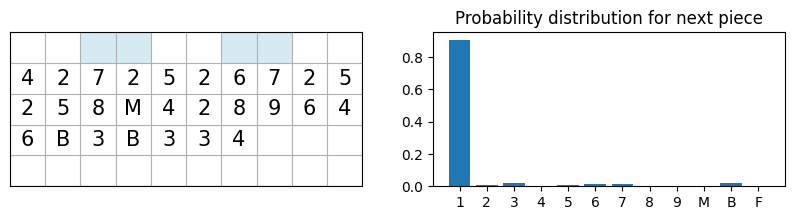

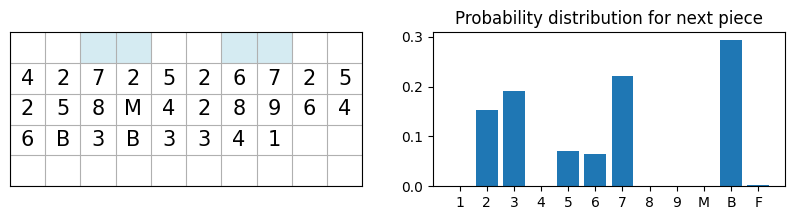

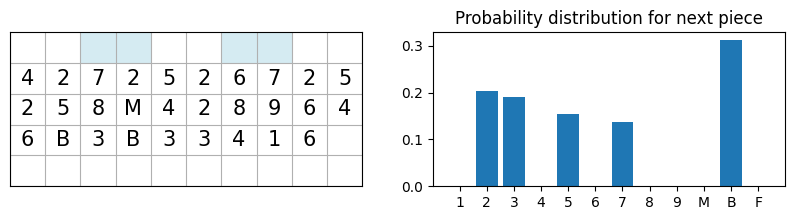

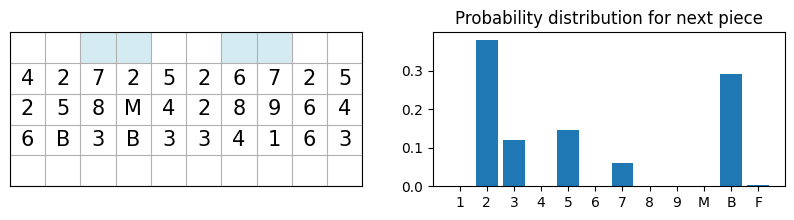

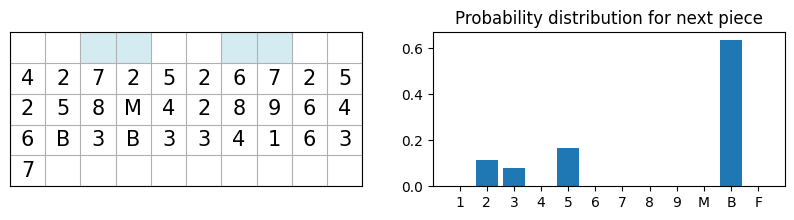

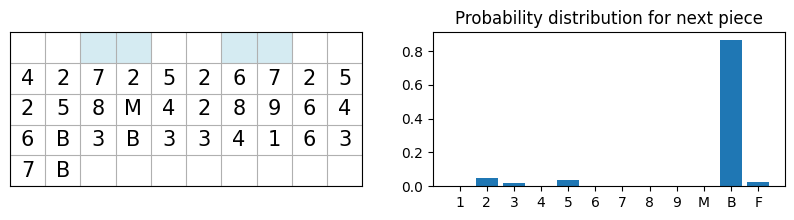

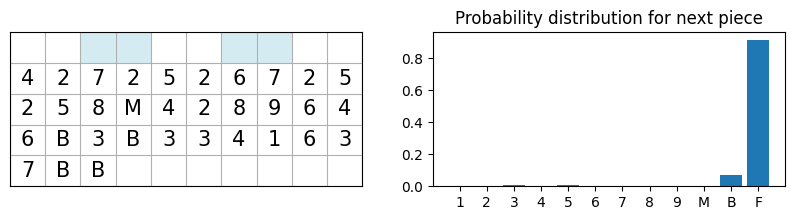

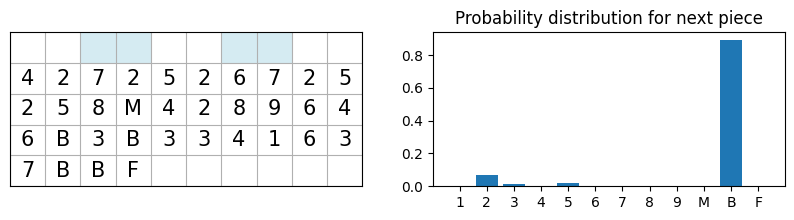

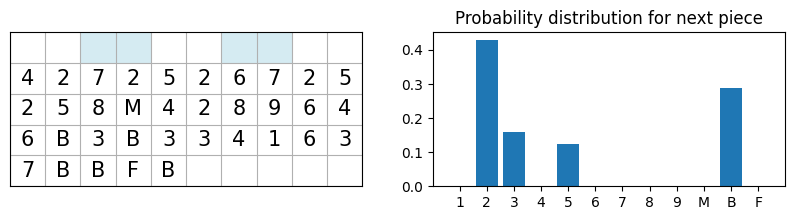

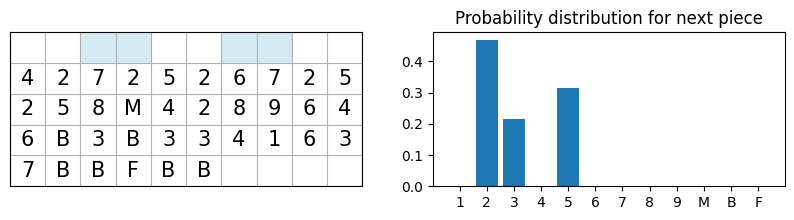

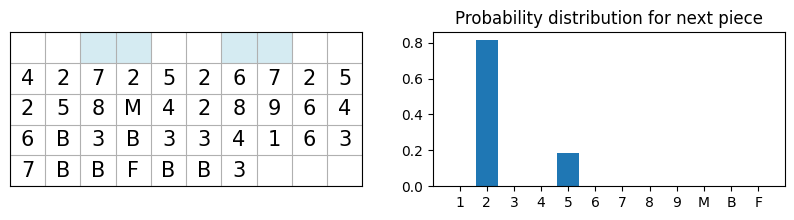

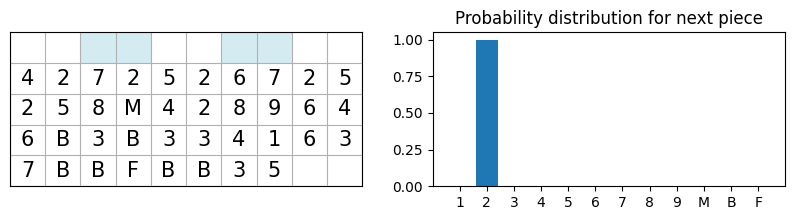

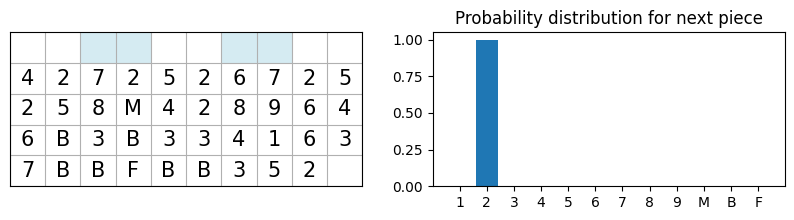

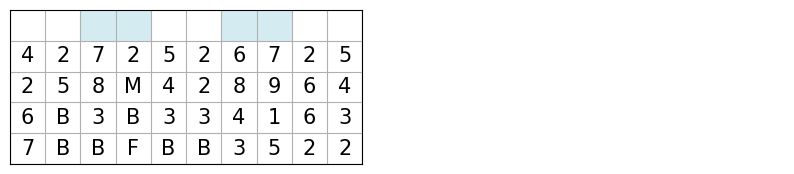

In [ ]:
setup, distributions = generate_setup(model)

for i in range(40):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 2))
    plot_setup(setup[:i], ax=ax1)
    ax2.set_title("Probability distribution for next piece")
    ax2.bar(HUMAN_READABLE.values(), distributions[i].detach())
    plt.show()
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 2))
plot_setup(setup, ax=ax1)
ax2.axis('off')
plt.show()